# 2. Preprocessing

Convert EEG data to learn model
1. Band-pass filter
2. Extract event (T1: left, T2: right)
3. Extract epochs

## 1. Environment settings

In [16]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mne
from src.preprocessing import preprocess_eeg_data


mne.set_log_level('WARNING')
np.random.seed(42)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 4)

edf_path = '../physionet.org/files/eegmmidb/1.0.0/S001/S001R03.edf'
raw = mne.io.read_raw_edf(edf_path, preload=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Data load and Data filtering

In [4]:
# Band-pass filter, filtering 8 (low frequency cut off) to 30 (high frequency cut off) hz
raw_filtered = raw.copy().filter(l_freq=8, h_freq=30)
raw_filtered

data = raw_filtered.get_data()
print(data.shape)
print(data)
print('\n')
print(f"Shape: {data.shape}")
print(f"Type: {data.dtype}")
print(f"Min: {data.min():.2e}")
print(f"Max: {data.max():.2e}")
print(f"Mean: {data.mean():.2e}")

print("First channel, first 10 samples:")
print(data[0, :10])

print("\nChannel names (first 5):")
print(raw_filtered.ch_names[:5])

(64, 20000)
[[ 1.35525272e-20  8.94971140e-06  6.72739024e-06 ...  4.55726947e-08
   2.64570192e-08  3.81164826e-21]
 [ 6.77626358e-21  5.44514773e-06  8.02105104e-07 ...  3.88759754e-08
   2.30629446e-08  4.23516474e-22]
 [ 1.01643954e-20  7.80918533e-06  6.47324117e-06 ... -2.18248078e-08
  -6.87607593e-09  4.23516474e-21]
 ...
 [-6.77626358e-21 -2.24109863e-06 -8.80968214e-08 ...  1.55919820e-07
   7.92396013e-08  3.38813179e-21]
 [-2.03287907e-20 -9.02833628e-06 -9.78521967e-06 ... -9.67071303e-08
  -5.17378112e-08 -1.69406589e-21]
 [ 2.71050543e-20  8.52391201e-07  8.12665690e-06 ...  1.03367272e-07
   4.73253372e-08  2.54109884e-21]]


Shape: (64, 20000)
Type: float64
Min: -1.64e-04
Max: 1.73e-04
Mean: 2.76e-10
First channel, first 10 samples:
[ 1.35525272e-20  8.94971140e-06  6.72739024e-06 -4.25776051e-06
 -1.11833453e-05 -6.12815008e-06  5.76461306e-06  1.37378258e-05
  1.33692242e-05  8.87286975e-06]

Channel names (first 5):
['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.']


## 3. Visualization

### 3.1 Comparasion band-pass filter

/tmp/ipykernel_4550/2745460270.py:4: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.compute_psd(fmax=80).plot(axes=axes[0], show=False)
/tmp/ipykernel_4550/2745460270.py:7: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw_filtered.compute_psd(fmax=80).plot(axes=axes[1], show=False)


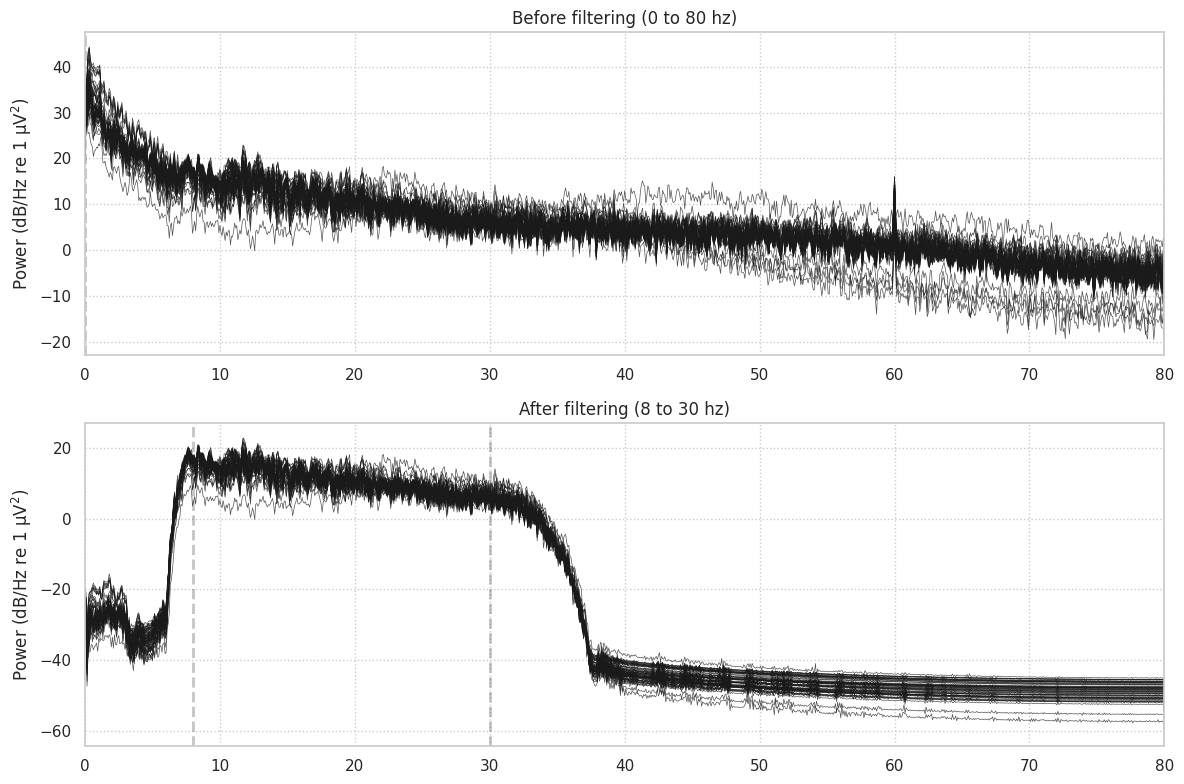

In [5]:
# Visualization
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

raw.compute_psd(fmax=80).plot(axes=axes[0], show=False)
axes[0].set_title('Before filtering (0 to 80 hz)')

raw_filtered.compute_psd(fmax=80).plot(axes=axes[1], show=False)
axes[1].set_title('After filtering (8 to 30 hz)')

plt.tight_layout()
plt.show()

### 3.2 Time domain (C3 index (channel))

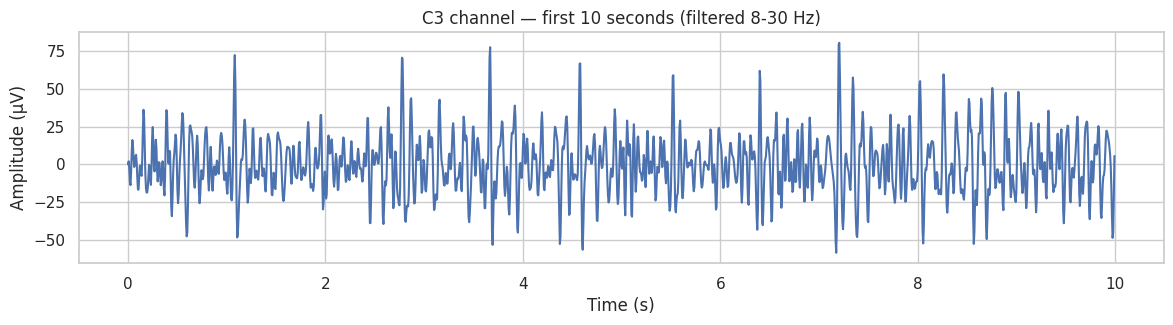

In [6]:
# C3 channel
c3_index = raw_filtered.ch_names.index('C3..')
c3_signal = data[c3_index]

# Making time
times = np.arange(len(c3_signal)) / 160

# show
plt.figure(figsize=(14, 3))
plt.plot(times[:1600], c3_signal[:1600] * 1e6)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')
plt.title('C3 channel — first 10 seconds (filtered 8-30 Hz)')
plt.show()

## 4. Extract event

In [11]:
events, event_id = mne.events_from_annotations(raw_filtered)

print(f"Event id: {event_id}")
print("\nFirst 5 events\n")
print(events[:5])
print(f"Shape: {events.shape}")

# Filtering T0
target_event_id = {'T1': event_id['T1'], 'T2': event_id['T2']}
epochs = mne.Epochs(
	raw_filtered,
	events,
	event_id=target_event_id,
	tmin=0,
	tmax=4,
	baseline=None,
	preload=True
)

epochs

Event id: {np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}

First 5 events

[[   0    0    1]
 [ 672    0    3]
 [1328    0    1]
 [2000    0    2]
 [2656    0    1]]
Shape: (30, 3)


<Epochs | 15 events (all good), 0 – 4 s (baseline off), ~4.7 MiB, data loaded,
 'T1': 8
 'T2': 7>

In [ ]:
# Convert to numpy array
X, y = preprocess_eeg_data(edf_path)

print(f"X shape:{X.shape}")
print(f"y shape:{y.shape}")
print(f"y value: {y}")
print(f"y unique: {np.unique(y)}")
event_id

X shape:(15, 64, 641)
y shape:(15,)
y value: [1 0 0 1 1 0 0 1 0 1 1 0 0 1 0]
y unique: [0 1]


{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}